# Ames Housing Price Prediction



In [75]:
from google.colab import files

uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [77]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [78]:
print(train.shape)
print(test.shape)


(1460, 81)
(1459, 80)


In [79]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [80]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [81]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [82]:
train.dtypes.value_counts()

,count
object,43
int64,35
float64,3


In [83]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


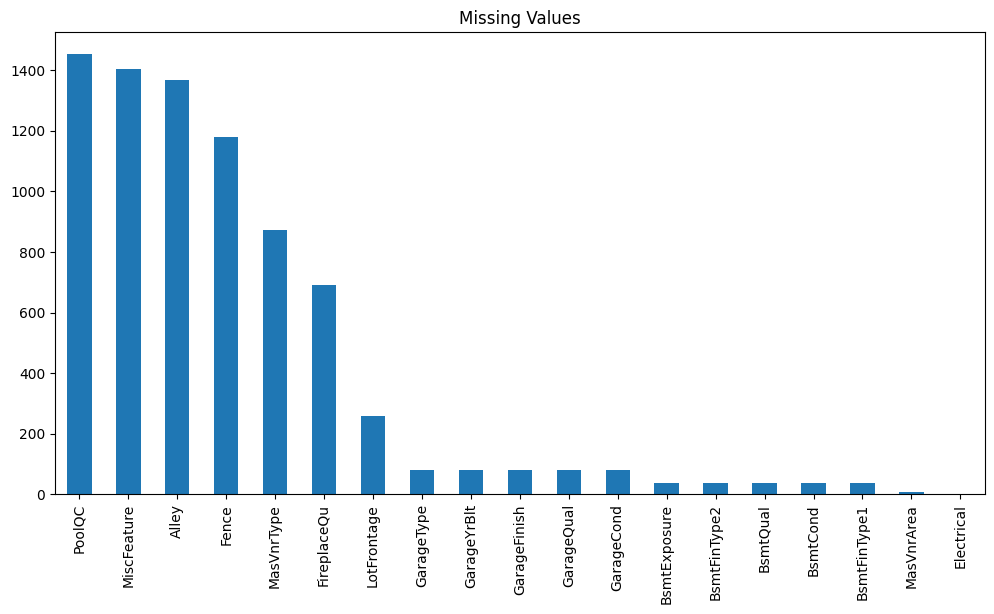

In [84]:
plt.figure(figsize=(12,6))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.show()

## Dataset Audit Summary

The dataset contains 1460 training observations and 79 explanatory variables.

Several columns contain structural missing values such as PoolQC, Alley and Fence where missing values indicate the absence of that feature.

Numerical features such as LotFrontage require statistical imputation.

SalePrice appears right skewed and will require transformation before modeling.

In [85]:
train_medians = train.median(numeric_only=True)

train_modes = {
    col: train[col].mode()[0]
    for col in train.select_dtypes(
        include="object"
)}

In [86]:
def fill_missing(df, medians, modes):

    df = df.copy()

    none_cols = [
        "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType",
        "GarageFinish", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType1",
        "BsmtFinType2", "BsmtQual", "BsmtCond"
        ]

    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].fillna(modes.get(col))

    for col in df.select_dtypes(exclude="object"):
        df[col] = df[col].fillna(medians.get(col))

    return df

In [87]:
train = fill_missing(
    train,
    train_medians,
    train_modes
)

test = fill_missing(
    test,
    train_medians,
    train_modes
)

In [88]:
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


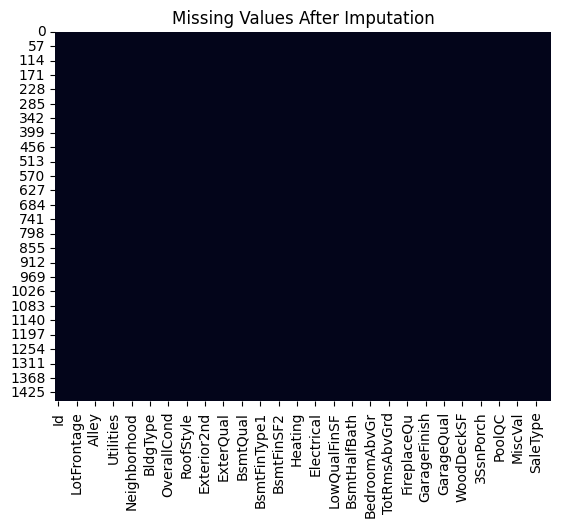

In [89]:
sns.heatmap(train.isnull(), cbar=False)

plt.title("Missing Values After Imputation")

plt.show()

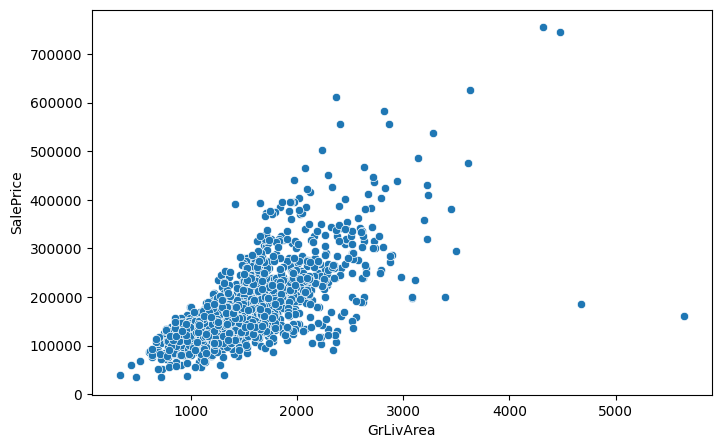

In [90]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"]
)

plt.show()

In [91]:
outliers = train[
    (train["GrLivArea"] > 4000)
    &
    (train["SalePrice"] < 300000)
]

outliers

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,...,0,None,None,None,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,...,480,Gd,None,None,0,1,2008,New,Partial,160000


In [92]:
train = train.drop(
    outliers.index
).copy()

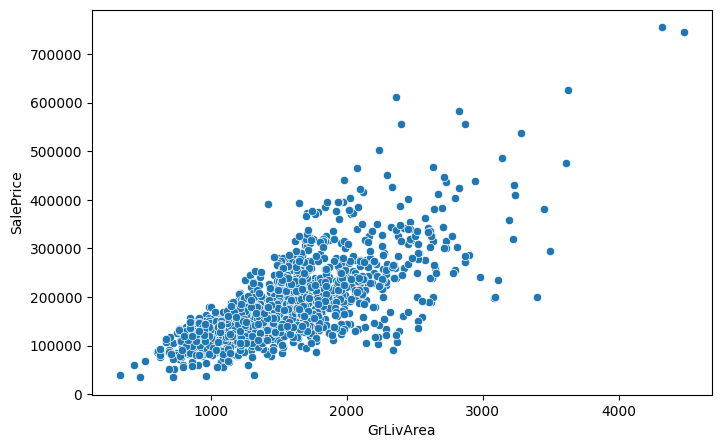

In [93]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"]
)

plt.show()

In [94]:
print(
    skew(train["SalePrice"])
)

1.8793604459195012


<Axes: xlabel='SalePrice', ylabel='Count'>

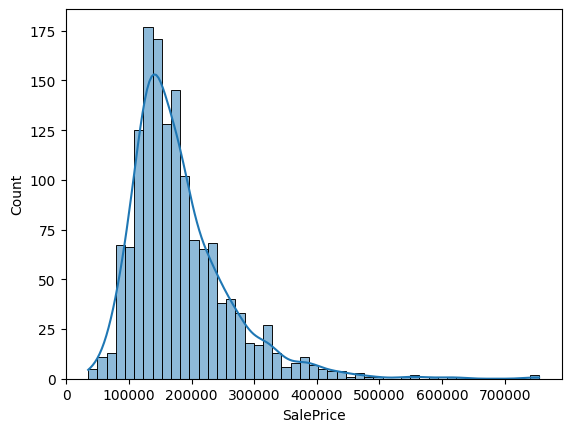

In [95]:
sns.histplot(
    train["SalePrice"],
    kde=True
)

In [96]:
train["SalePrice"] = np.log1p(train["SalePrice"])

In [97]:
print(skew(train["SalePrice"]))

0.12145464268184528


<Axes: xlabel='SalePrice', ylabel='Count'>

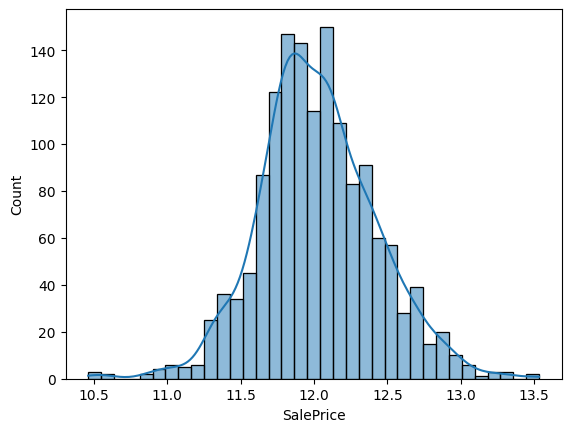

In [98]:
sns.histplot(train["SalePrice"], kde=True)

In [99]:
numeric_cols = train.select_dtypes(exclude="object").columns

skewness = train[numeric_cols].apply(lambda x: skew(x.dropna()))

skewed_features = skewness[abs(skewness) > 0.75].index

In [100]:
for col in skewed_features:

    train[col] = np.log1p(train[col])

    if col in test.columns:
        test[col] = np.log1p(test[col])

In [101]:
quality_map = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}

In [102]:
quality_cols = [

"ExterQual",
"KitchenQual",
"BsmtQual",
"FireplaceQu",
"GarageQual",
"HeatingQC",
"PoolQC"

]

In [103]:
for col in quality_cols:

    train[col] = train[col].map(quality_map)

    test[col] = test[col].map(quality_map)

In [104]:
train["MSSubClass"] = (
    train["MSSubClass"]
    .astype(str)
)

test["MSSubClass"] = (
    test["MSSubClass"]
    .astype(str)
)

In [105]:
y = train["SalePrice"]

train = train.drop(
    "SalePrice",
    axis=1
)

In [106]:
train["TotalSF"] = (train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"])

test["TotalSF"] = (test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"])


train["HouseAge"] = (train["YrSold"] - train["YearBuilt"])

test["HouseAge"] = (test["YrSold"] - test["YearBuilt"])


train["RemodelAge"] = (train["YrSold"] - train["YearRemodAdd"])

test["RemodelAge"] = (test["YrSold"] - test["YearRemodAdd"])


train["TotalBath"] = (train["FullBath"] + 0.5*train["HalfBath"] + train["BsmtFullBath"] + 0.5*train["BsmtHalfBath"])

test["TotalBath"] = (test["FullBath"] + 0.5*test["HalfBath"] + test["BsmtFullBath"] + 0.5*test["BsmtHalfBath"])


train["HasPool"] = (train["PoolArea"] > 0).astype(int)

test["HasPool"] = (test["PoolArea"] > 0).astype(int)

train["HasGarage"] = (train["GarageCars"] > 0).astype(int)

test["HasGarage"] = (test["GarageCars"] > 0).astype(int)

train["HasFireplace"] = (train["Fireplaces"] > 0).astype(int)

test["HasFireplace"] = (test["Fireplaces"] > 0).astype(int)

In [107]:
all_data = pd.concat([train,test], axis=0)

In [108]:
all_data = pd.get_dummies(all_data, drop_first=True)

In [109]:
train = all_data.iloc[:len(train)]
test = all_data.iloc[len(train):]
print(train.shape)
print(test.shape)

(1458, 259)
(1459, 259)


In [110]:
corr_matrix = train.corr()

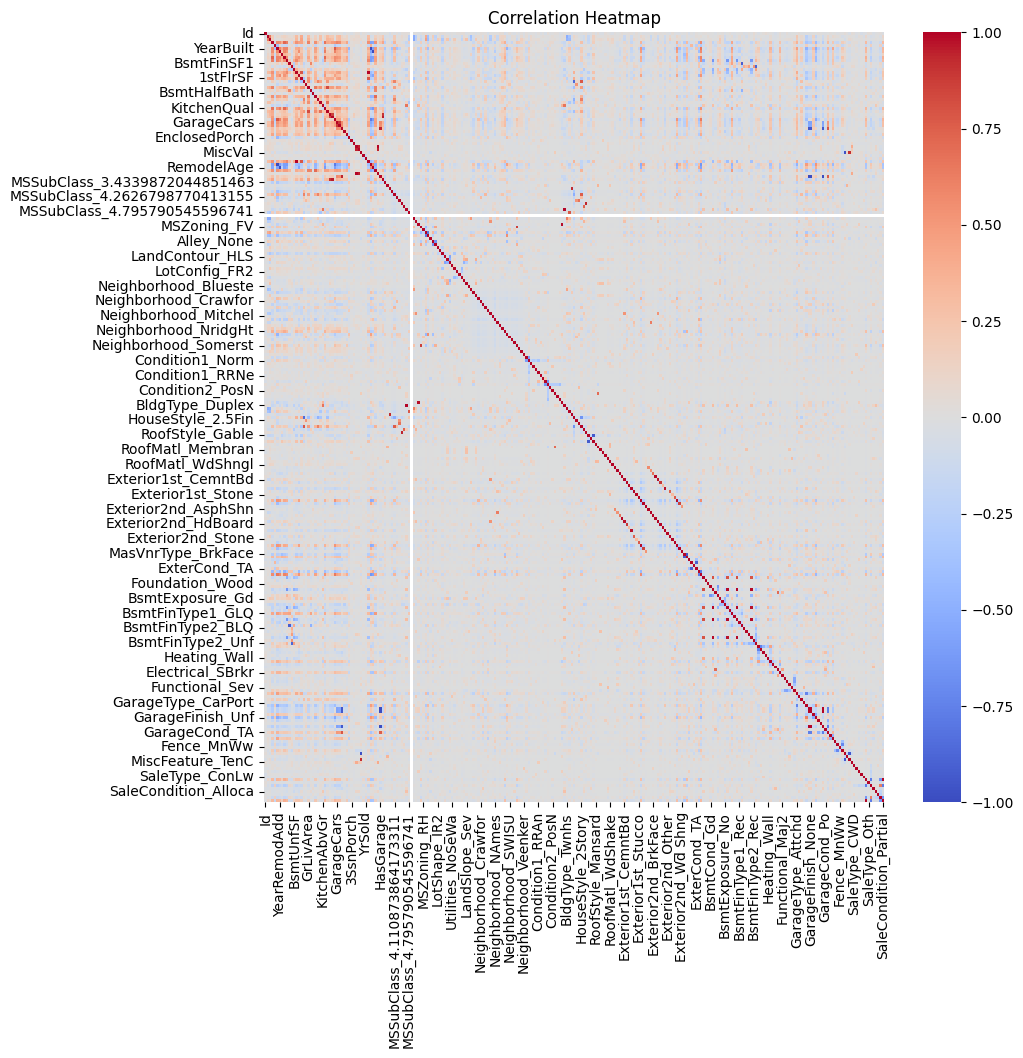

In [111]:
plt.figure(figsize=(10,10))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap")

plt.show()

In [112]:
corr_matrix = train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

In [113]:
high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.85)
]

print(high_corr)

['FireplaceQu', 'GarageArea', 'PoolQC', 'TotalSF', 'HouseAge', 'RemodelAge', 'HasPool', 'HasGarage', 'HasFireplace', 'Neighborhood_Somerst', 'BldgType_2fmCon', 'BldgType_Duplex', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_SLvl', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'MasVnrType_Stone', 'ExterCond_TA', 'BsmtExposure_None', 'BsmtFinType1_None', 'BsmtFinType1_Unf', 'BsmtFinType2_None', 'BsmtFinType2_Unf', 'GarageType_None', 'GarageFinish_None', 'GarageCond_None', 'MiscFeature_None', 'MiscFeature_Shed', 'SaleCondition_Partial']


In [114]:
train.drop(columns=high_corr, inplace=True, errors="ignore")

test.drop(columns=high_corr, inplace=True, errors="ignore")

/tmp/ipykernel_18125/1465855463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(columns=high_corr, inplace=True, errors="ignore")
/tmp/ipykernel_18125/1465855463.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(columns=high_corr, inplace=True, errors="ignore")


In [115]:
print(train.shape)

print(test.shape)

(1458, 224)
(1459, 224)


In [116]:
X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.20, random_state=42)

In [117]:
print(X_train.shape)

print(X_val.shape)

(1166, 224)
(292, 224)


In [118]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [119]:
ridge = RidgeCV(alphas=[0.1, 1, 10, 50, 100])

ridge.fit(X_train, y_train)

RidgeCV(alphas=[0.1, 1, 10, 50, 100])

In [120]:
lasso = LassoCV(cv=5, random_state=42)

lasso.fit(X_train, y_train)

LassoCV(cv=5, random_state=42)

In [121]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [122]:
gbr = GradientBoostingRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=4,
    max_features="sqrt",
    min_samples_leaf=15,
    min_samples_split=10,
    loss="huber",
    random_state=42
)

In [123]:
models = {

    "Linear Regression": lr,

    "Ridge Regression": ridge,

    "Lasso Regression": lasso,

    "Random Forest": rf,

    "Gradient Boosting": gbr
}

results = []

In [124]:
for name, model in models.items():

    rmse = np.sqrt(-cross_val_score(model, train, y, cv=5, scoring="neg_mean_squared_error")).mean()

    results.append([name, rmse])

In [125]:
results = pd.DataFrame(results, columns=["Model", "CV_RMSE"])

results.sort_values("CV_RMSE")

,Model,CV_RMSE
4,Gradient Boosting,0.114850
1,Ridge Regression,0.114920
0,Linear Regression,0.122803
3,Random Forest,0.137703
2,Lasso Regression,0.210190


In [126]:
best_model_name = results.sort_values(
    "CV_RMSE"
).iloc[0]["Model"]

print(
    "Best Model:",
    best_model_name
)

Best Model: Gradient Boosting


In [127]:
best_model = gbr

best_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, loss='huber', max_depth=4,
                          max_features='sqrt', min_samples_leaf=15,
                          min_samples_split=10, n_estimators=3000,
                          random_state=42)

In [128]:
pred = best_model.predict(
    X_val
)

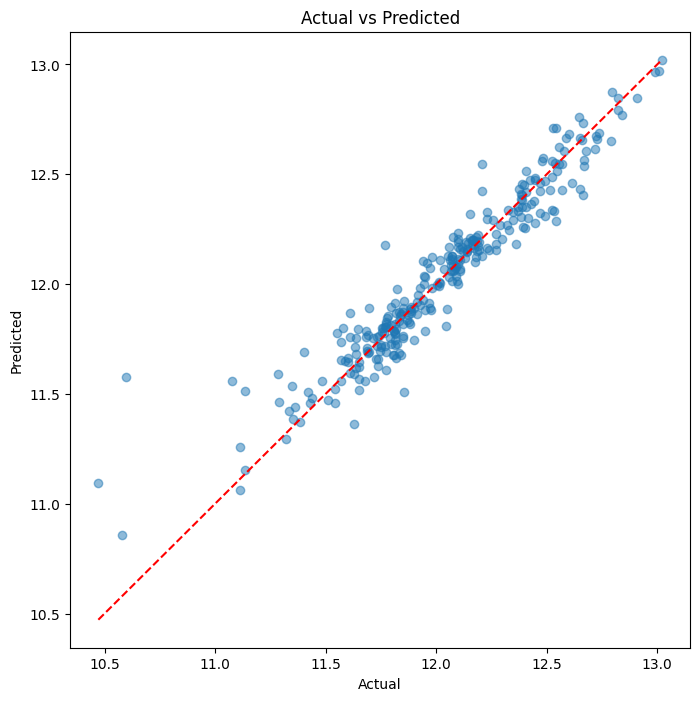

In [129]:
plt.figure(figsize=(8,8))

plt.scatter(y_val, pred, alpha=0.5)

plt.plot(

    [y_val.min(),y_val.max()],
    [y_val.min(), y_val.max()],
    "r--"
    )

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [130]:
residuals = (y_val - pred)

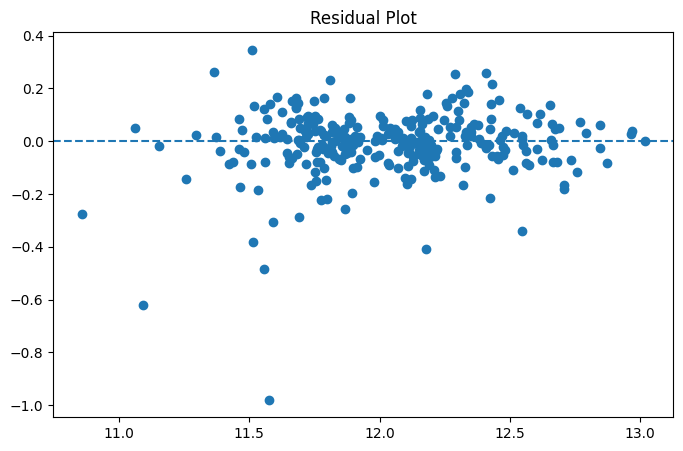

In [131]:
plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")

plt.show()

In [132]:
importance = pd.Series(
    rf.feature_importances_,
    index=train.columns
)

In [133]:
top20 = importance.sort_values(ascending=False).head(20)

top20

,0
OverallQual,0.529907
GrLivArea,0.104369
TotalBsmtSF,0.047496
GarageCars,0.046789
TotalBath,0.045394
1stFlrSF,0.027327
CentralAir_Y,0.016542
BsmtFinSF1,0.016333
LotArea,0.014680
YearBuilt,0.011928


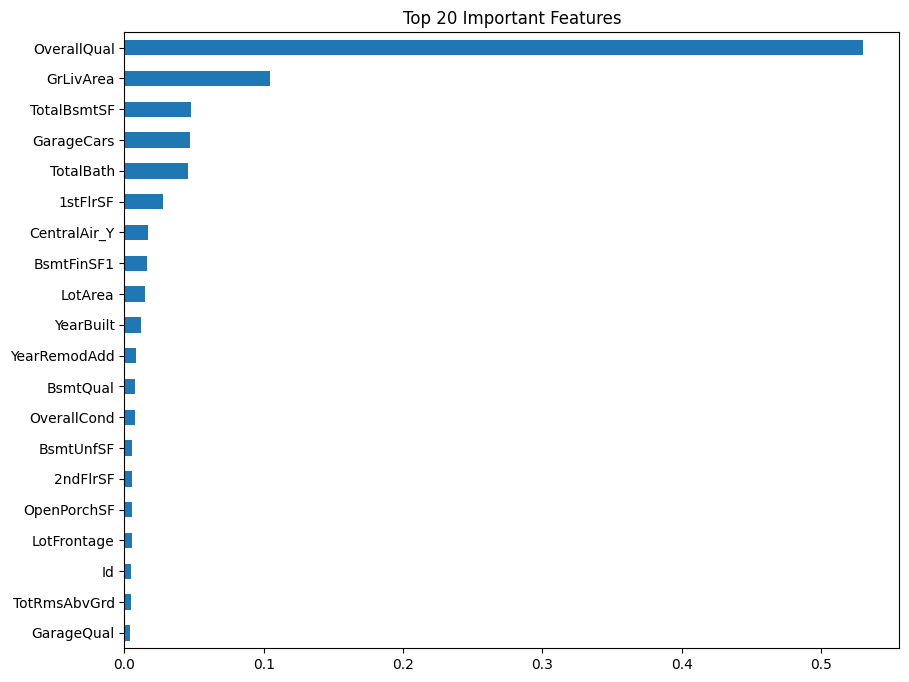

In [134]:
plt.figure(figsize=(10,8))

top20.sort_values().plot(kind="barh")

plt.title("Top 20 Important Features")

plt.show()

In [135]:
original_train = pd.read_csv("train.csv")

In [136]:
neighborhood_mean = original_train.groupby("Neighborhood")["SalePrice"].mean()

neighborhood_mean.sort_values(ascending=False).head(10)

,SalePrice
Neighborhood,
NoRidge,335295.317073
NridgHt,316270.623377
StoneBr,310499.000000
Timber,242247.447368
Veenker,238772.727273
Somerst,225379.837209
ClearCr,212565.428571
Crawfor,210624.725490
CollgCr,197965.773333


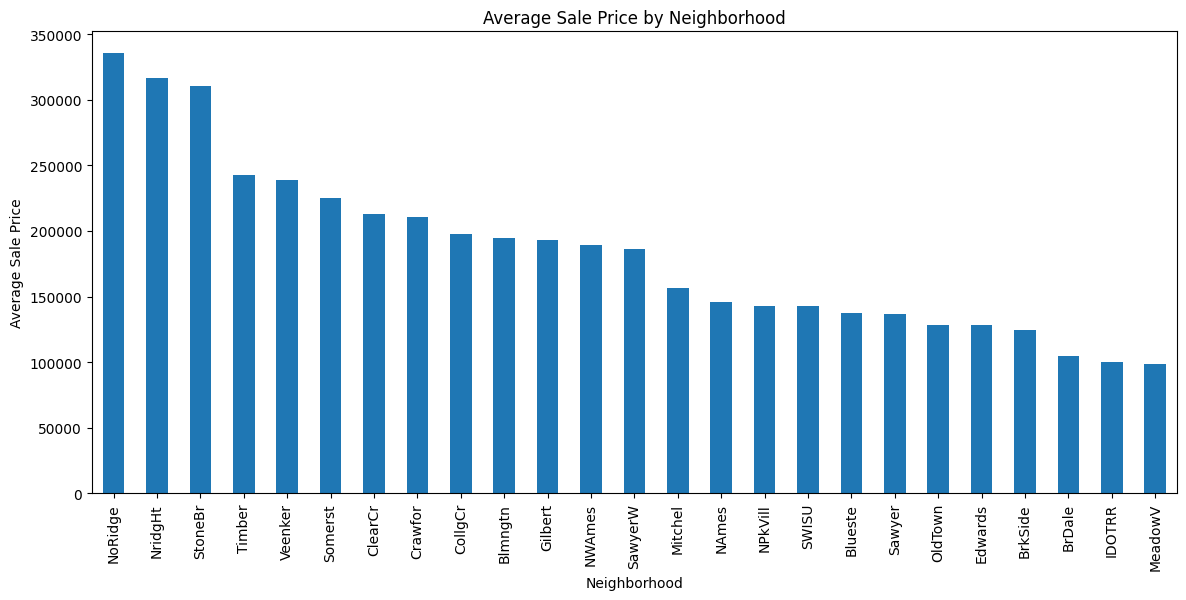

In [137]:
plt.figure(figsize=(14,6))

neighborhood_mean.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Sale Price by Neighborhood")

plt.ylabel("Average Sale Price")

plt.show()

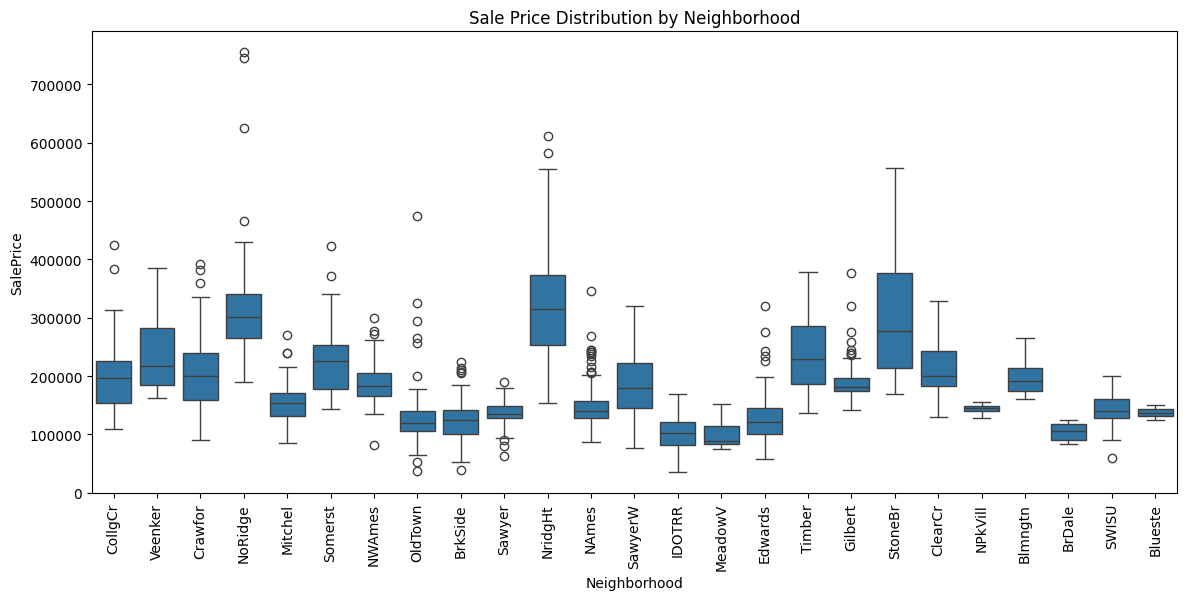

In [138]:
plt.figure(figsize=(14,6))

sns.boxplot(data=original_train, x="Neighborhood", y="SalePrice")

plt.xticks(rotation=90)

plt.title("Sale Price Distribution by Neighborhood")

plt.show()

In [139]:
clean_train = train.copy()

clean_train["SalePrice"] = y

clean_train.to_csv("clean_train.csv", index=False)

test.to_csv("clean_test.csv", index=False)

In [140]:
predictions_log = best_model.predict(test)

In [141]:
predictions = np.expm1(predictions_log)

In [142]:
test_original = pd.read_csv("test.csv")

In [143]:
submission = pd.DataFrame({

    "Id":
    test_original["Id"],

    "SalePrice":
    predictions
})

In [144]:
submission.to_csv(
    "submission.csv",
    index=False
)

print(
    "Submission Created Successfully"
)

Submission Created Successfully


In [145]:
submission.head()

,Id,SalePrice
0,1461,119329.858665
1,1462,157888.645306
2,1463,202052.609444
3,1464,208203.815439
4,1465,194990.265586
